### AnalystLab Africa

# =======================================================
# Projet d'analyse de Netflix
# =======================================================

In [60]:
#Importation des bibliothèques 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [61]:
# Charger le dataset Netflix
df = pd.read_csv(r"C:\Users\HP ProBook\Desktop\AnalystLab Africa\netflix_titles\netflix_titles.csv")

# Familariisation avec le dataset

In [62]:
# Vérifier la structure
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [63]:
# Affichons les dimensions du dataset
df.shape

(8807, 12)

In [64]:
# Information générale sur le dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [65]:
# Statistique descriptive
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


# Nettoyage des données & Normalisation

In [66]:
# Valeurs manquantes
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [67]:
# vérifions le nombre de doublons
df.duplicated().sum()

np.int64(0)

In [68]:
# Affichons les lignes où le réalisateur est manquant
df[df["director"].isnull()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
10,s11,TV Show,"Vendetta: Truth, Lies and The Mafia",NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, Docuseries, International TV S...","Sicily boasts a bold ""Anti-Mafia"" coalition. B..."
14,s15,TV Show,Crime Stories: India Detectives,NaN,NaN,NaN,"September 22, 2021",2021,TV-MA,1 Season,"British TV Shows, Crime TV Shows, Docuseries",Cameras following Bengaluru police on the job ...
15,s16,TV Show,Dear White People,NaN,"Logan Browning, Brandon P. Bell, DeRon Horton,...",United States,"September 22, 2021",2021,TV-MA,4 Seasons,"TV Comedies, TV Dramas",Students of color navigate the daily slights a...
17,s18,TV Show,Falsa identidad,NaN,"Luis Ernesto Franco, Camila Sodi, Sergio Goyri...",Mexico,"September 22, 2021",2020,TV-MA,2 Seasons,"Crime TV Shows, Spanish-Language TV Shows, TV ...",Strangers Diego and Isabel flee their home in ...
19,s20,TV Show,Jaguar,NaN,"Blanca Suárez, Iván Marcos, Óscar Casas, Adriá...",NaN,"September 22, 2021",2021,TV-MA,1 Season,"International TV Shows, Spanish-Language TV Sh...","In the 1960s, a Holocaust survivor joins a gro..."
21,s22,TV Show,Resurrection: Ertugrul,NaN,"Engin Altan Düzyatan, Serdar Gökhan, Hülya Dar...",Turkey,"September 22, 2021",2018,TV-14,5 Seasons,"International TV Shows, TV Action & Adventure,...",When a good deed unwittingly endangers his cla...
25,s26,TV Show,Love on the Spectrum,NaN,Brooke Satchwell,Australia,"September 21, 2021",2021,TV-14,2 Seasons,"Docuseries, International TV Shows, Reality TV",Finding love can be hard for anyone. For young...


In [69]:
# Comptons le nombre de films et de séries TV dont le réalisateur est manquant
df[df["director"].isnull()]["type"].value_counts()

type
TV Show    2446
Movie       188
Name: count, dtype: int64

## Conclusion sur la colonne `director`

Après analyse, la colonne `director` contient **2 634 valeurs manquantes**.

La répartition montre que :
- TV Show : **2 446**
- Movie : **188**

Les valeurs manquantes concernent donc principalement les séries TV. Nous avons décidé de **ne pas supprimer ces lignes**, car cela entraînerait une perte importante de données et pourrait fausser les analyses. Ces valeurs manquantes semblent correspondre à une absence d'information plutôt qu'à une erreur de collecte.

In [70]:
# Affichons les lignes où les acteurs sont manquants(10 premières)
df[df["cast"].isnull()].head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
10,s11,TV Show,"Vendetta: Truth, Lies and The Mafia",NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, Docuseries, International TV S...","Sicily boasts a bold ""Anti-Mafia"" coalition. B..."
14,s15,TV Show,Crime Stories: India Detectives,NaN,NaN,NaN,"September 22, 2021",2021,TV-MA,1 Season,"British TV Shows, Crime TV Shows, Docuseries",Cameras following Bengaluru police on the job ...
16,s17,Movie,Europe's Most Dangerous Man: Otto Skorzeny in ...,"Pedro de Echave García, Pablo Azorín Williams",NaN,NaN,"September 22, 2021",2020,TV-MA,67 min,"Documentaries, International Movies",Declassified documents reveal the post-WWII li...
20,s21,TV Show,Monsters Inside: The 24 Faces of Billy Milligan,Olivier Megaton,NaN,NaN,"September 22, 2021",2021,TV-14,1 Season,"Crime TV Shows, Docuseries, International TV S...","In the late 1970s, an accused serial rapist cl..."
45,s46,Movie,My Heroes Were Cowboys,Tyler Greco,NaN,NaN,"September 16, 2021",2021,PG,23 min,Documentaries,Robin Wiltshire's painful childhood was rescue...
66,s67,TV Show,Raja Rasoi Aur Anya Kahaniyan,NaN,NaN,India,"September 15, 2021",2014,TV-G,1 Season,"Docuseries, International TV Shows",Explore the history and flavors of regional In...
69,s70,TV Show,Stories by Rabindranath Tagore,NaN,NaN,India,"September 15, 2021",2015,TV-PG,1 Season,"International TV Shows, TV Dramas",The writings of Nobel Prize winner Rabindranat...
74,s75,TV Show,The World's Most Amazing Vacation Rentals,NaN,NaN,NaN,"September 14, 2021",2021,TV-PG,2 Seasons,Reality TV,"With an eye for every budget, three travelers ..."


In [71]:
# Comptons le nombre de films et de séries TV dont les acteurs sont manquants
df[df["cast"].isnull()]["type"].value_counts()

type
Movie      475
TV Show    350
Name: count, dtype: int64

### Conclusion :
La colonne 'cast' contient 825 valeurs manquantes.
Elles concernent 475 films et 350 séries TV.
Nous choisissons de conserver ces lignes, car l'absence du nom des acteurs n'empêche pas les autres analyses du dataset.

In [72]:
# Affichons les lignes où le pays est manquant(10 premières)
df[df["country"].isnull()].head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
10,s11,TV Show,"Vendetta: Truth, Lies and The Mafia",NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, Docuseries, International TV S...","Sicily boasts a bold ""Anti-Mafia"" coalition. B..."
11,s12,TV Show,Bangkok Breaking,Kongkiat Komesiri,"Sukollawat Kanarot, Sushar Manaying, Pavarit M...",NaN,"September 23, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...","Struggling to earn a living in Bangkok, a man ..."
13,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,"Klara Castanho, Lucca Picon, Júlia Gomes, Marc...",NaN,"September 22, 2021",2021,TV-PG,91 min,"Children & Family Movies, Comedies",When the clever but socially-awkward Tetê join...
14,s15,TV Show,Crime Stories: India Detectives,NaN,NaN,NaN,"September 22, 2021",2021,TV-MA,1 Season,"British TV Shows, Crime TV Shows, Docuseries",Cameras following Bengaluru police on the job ...
16,s17,Movie,Europe's Most Dangerous Man: Otto Skorzeny in ...,"Pedro de Echave García, Pablo Azorín Williams",NaN,NaN,"September 22, 2021",2020,TV-MA,67 min,"Documentaries, International Movies",Declassified documents reveal the post-WWII li...
18,s19,Movie,Intrusion,Adam Salky,"Freida Pinto, Logan Marshall-Green, Robert Joh...",NaN,"September 22, 2021",2021,TV-14,94 min,Thrillers,After a deadly home invasion at a couple’s new...


In [73]:
# Compter le nombre de films et de séries TV dont le pays est manquant
df[df["country"].isnull()]["type"].value_counts()

type
Movie      440
TV Show    391
Name: count, dtype: int64

In [74]:
# Afficher les 10 réalisateurs les plus fréquents lorsque le pays est manquant
df[df["country"].isnull()]["director"].value_counts().head(10)

director
Rajiv Chilaka                           16
Suhas Kadav                             15
Prakash Satam                            7
Hidenori Inoue                           6
Joey So                                  6
S.S. Rajamouli                           5
Rathindran R Prasad                      4
Leigh Janiak                             3
Yoshiyuki Tomino, Yoshikazu Yasuhiko     3
Adriano Rudiman                          3
Name: count, dtype: int64

In [75]:
# Recherche d'une methode fiable pour complèter les données

In [76]:
# Afficher les pays des œuvres de Rajiv Chilaka lorsque le pays est renseigné
df[(df["director"] == "Rajiv Chilaka") & (df["country"].notnull())]["country"].value_counts()

country
India    3
Name: count, dtype: int64

In [77]:
# Vérifier les pays associés aux œuvres de Suhas Kadav
df[(df["director"] == "Suhas Kadav") & (df["country"].notnull())]["country"].value_counts()

country
India    1
Name: count, dtype: int64

In [78]:
# Vérifier les pays associés aux œuvres de Prakash Satam
df[(df["director"] == "Prakash Satam") & (df["country"].notnull())]["country"].value_counts()

Series([], Name: count, dtype: int64)

In [79]:
# Compter les pays associés à chaque réalisateur ayant des valeurs country manquantes

df[df["country"].isnull()]["director"].dropna().to_frame().merge(
    df[df["country"].notnull()][["director", "country"]],
    on="director",
    how="left"
).groupby(["director", "country"]).size().reset_index(name="nombre")

,director,country,nombre
0,A.R. Murugadoss,India,1
1,Abhijit Panse,India,1
2,Ahishor Solomon,India,1
3,Ahmad El-Badri,Egypt,3
4,Ahmed Al-Badry,Egypt,2
5,"Alex Woo, Stanley Moore",United States,2
6,Anthony Giordano,United States,1
7,Ashwin Saravanan,"India, Turkey",2
8,B. V. Nandini Reddy,India,2
9,Ben Simms,United States,1


In [80]:
# Compter le nombre de valeurs 'country' manquantes pour chaque réalisateur
directors_missing = (
    df[df["country"].isnull()]["director"]
    .value_counts()
    .reset_index()
)

# Renommer les colonnes
directors_missing.columns = ["director", "missing_country_count"]

# Afficher toutes les lignes du DataFrame
import pandas as pd
pd.set_option("display.max_rows", None)

directors_missing


,director,missing_country_count
0,Rajiv Chilaka,16
1,Suhas Kadav,15
2,Prakash Satam,7
3,Hidenori Inoue,6
4,Joey So,6
5,S.S. Rajamouli,5
6,Rathindran R Prasad,4
7,Leigh Janiak,3
8,"Yoshiyuki Tomino, Yoshikazu Yasuhiko",3
9,Adriano Rudiman,3


In [81]:
# Corriger uniquement les cas certains

In [82]:
# Identifier les réalisateurs associés à un seul pays connu
director_country = (
    df[df["country"].notnull()]
    .groupby("director")["country"]
    .nunique()
)

# Conserver uniquement les réalisateurs ayant un seul pays connu
director_country = director_country[director_country == 1]

In [83]:
# Créer un dictionnaire : réalisateur -> pays
director_country_map = (
    df[df["director"].isin(director_country.index)]
    .groupby("director")["country"]
    .first()
)

In [84]:
# Remplacer uniquement les valeurs manquantes de 'country'
df.loc[df["country"].isnull(), "country"] = (
    df.loc[df["country"].isnull(), "director"]
      .map(director_country_map)
)

In [85]:
# Vérifier le nombre de valeurs manquantes restantes
df["country"].isnull().sum()

np.int64(698)

# Conclusion :
La colonne 'country' contenait initialement 831 valeurs manquantes.
 Après analyse, nous avons constaté que certains réalisateurs étaient
 associés à un seul pays connu, tandis que d'autres étaient associés à
 plusieurs pays.
#
 Afin de préserver la qualité des données, nous avons remplacé uniquement
 les valeurs manquantes pour les réalisateurs ayant un seul pays connu.
 Cette méthode a permis de corriger 133 valeurs.
#
 Les 698 valeurs restantes ont été conservées, car aucune information
 suffisamment fiable ne permettait de les compléter automatiquement.

In [86]:
# Afficher les lignes où la date d'ajout est manquante
df[df["date_added"].isnull()].head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
6066,s6067,TV Show,A Young Doctor's Notebook and Other Stories,NaN,"Daniel Radcliffe, Jon Hamm, Adam Godley, Chris...",United Kingdom,NaN,2013,TV-MA,2 Seasons,"British TV Shows, TV Comedies, TV Dramas","Set during the Russian Revolution, this comic ..."
6174,s6175,TV Show,Anthony Bourdain: Parts Unknown,NaN,Anthony Bourdain,United States,NaN,2018,TV-PG,5 Seasons,Docuseries,This CNN original series has chef Anthony Bour...
6795,s6796,TV Show,Frasier,NaN,"Kelsey Grammer, Jane Leeves, David Hyde Pierce...",United States,NaN,2003,TV-PG,11 Seasons,"Classic & Cult TV, TV Comedies",Frasier Crane is a snooty but lovable Seattle ...
6806,s6807,TV Show,Friends,NaN,"Jennifer Aniston, Courteney Cox, Lisa Kudrow, ...",United States,NaN,2003,TV-14,10 Seasons,"Classic & Cult TV, TV Comedies",This hit sitcom follows the merry misadventure...
6901,s6902,TV Show,Gunslinger Girl,NaN,"Yuuka Nanri, Kanako Mitsuhashi, Eri Sendai, Am...",Japan,NaN,2008,TV-14,2 Seasons,"Anime Series, Crime TV Shows","On the surface, the Social Welfare Agency appe..."
7196,s7197,TV Show,Kikoriki,NaN,Igor Dmitriev,NaN,NaN,2010,TV-Y,2 Seasons,Kids' TV,A wacky rabbit and his gang of animal pals hav...
7254,s7255,TV Show,La Familia P. Luche,NaN,"Eugenio Derbez, Consuelo Duval, Luis Manuel Áv...",United States,NaN,2012,TV-14,3 Seasons,"International TV Shows, Spanish-Language TV Sh...","This irreverent sitcom featues Ludovico, Feder..."
7406,s7407,TV Show,Maron,NaN,"Marc Maron, Judd Hirsch, Josh Brener, Nora Zeh...",United States,NaN,2016,TV-MA,4 Seasons,TV Comedies,"Marc Maron stars as Marc Maron, who interviews..."
7847,s7848,TV Show,Red vs. Blue,NaN,"Burnie Burns, Jason Saldaña, Gustavo Sorola, G...",United States,NaN,2015,NR,13 Seasons,"TV Action & Adventure, TV Comedies, TV Sci-Fi ...","This parody of first-person shooter games, mil..."
8182,s8183,TV Show,The Adventures of Figaro Pho,NaN,"Luke Jurevicius, Craig Behenna, Charlotte Haml...",Australia,NaN,2015,TV-Y7,2 Seasons,"Kids' TV, TV Comedies","Imagine your worst fears, then multiply them: ..."


In [87]:
# Compter les films et les séries TV dont la date d'ajout est manquante
df[df["date_added"].isnull()]["type"].value_counts()

type
TV Show    10
Name: count, dtype: int64

In [88]:
# Vérifier les années de sortie des contenus dont la date d'ajout est manquante
df[df["date_added"].isnull()]["release_year"].value_counts().sort_index()

release_year
2003    2
2008    1
2010    1
2012    1
2013    1
2015    2
2016    1
2018    1
Name: count, dtype: int64

## Conclusion :
La colonne 'date_added' contient 10 valeurs manquantes.
Toutes concernent des séries TV.
Étant donné leur faible proportion (10 sur 8 807 lignes) et l'absence d'information fiable permettant de retrouver la date exacte, ces valeurs sont conservées telles quelles.

In [89]:
# Afficher les lignes où la classification d'âge (rating) est manquante
df[df["rating"].isnull()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5989,s5990,Movie,13TH: A Conversation with Oprah Winfrey & Ava ...,NaN,"Oprah Winfrey, Ava DuVernay",NaN,"January 26, 2017",2017,NaN,37 min,Movies,Oprah Winfrey sits down with director Ava DuVe...
6827,s6828,TV Show,Gargantia on the Verdurous Planet,NaN,"Kaito Ishikawa, Hisako Kanemoto, Ai Kayano, Ka...",Japan,"December 1, 2016",2013,NaN,1 Season,"Anime Series, International TV Shows","After falling through a wormhole, a space-dwel..."
7312,s7313,TV Show,Little Lunch,NaN,"Flynn Curry, Olivia Deeble, Madison Lu, Oisín ...",Australia,"February 1, 2018",2015,NaN,1 Season,"Kids' TV, TV Comedies","Adopting a child's perspective, this show take..."
7537,s7538,Movie,My Honor Was Loyalty,Alessandro Pepe,"Leone Frisa, Paolo Vaccarino, Francesco Miglio...",Italy,"March 1, 2017",2015,NaN,115 min,Dramas,"Amid the chaos and horror of World War II, a c..."


In [90]:
# Afficher les colonnes les plus utiles où la classification d'âge (rating) est manquante
df[df["rating"].isnull()][["title", "type", "country", "release_year", "duration", "listed_in"]]

,title,type,country,release_year,duration,listed_in
5989,13TH: A Conversation with Oprah Winfrey & Ava ...,Movie,NaN,2017,37 min,Movies
6827,Gargantia on the Verdurous Planet,TV Show,Japan,2013,1 Season,"Anime Series, International TV Shows"
7312,Little Lunch,TV Show,Australia,2015,1 Season,"Kids' TV, TV Comedies"
7537,My Honor Was Loyalty,Movie,Italy,2015,115 min,Dramas


# Conclusion :
La colonne 'rating' contient 4 valeurs manquantes.   
Après vérification, aucune information du dataset ne permet de retrouver
le rating de ces contenus.   Les valeurs sont donc conservées.

In [91]:
 # Afficher les informations utiles des contenus dont la durée est manquante
df[df["duration"].isnull()][["title", "type", "release_year", "rating", "listed_in"]]

,title,type,release_year,rating,listed_in
5541,Louis C.K. 2017,Movie,2017,74 min,Movies
5794,Louis C.K.: Hilarious,Movie,2010,84 min,Movies
5813,Louis C.K.: Live at the Comedy Store,Movie,2015,66 min,Movies


In [92]:
# Vérifier si ces films apparaissent plusieurs fois dans le dataset
df[df["title"].str.contains("Louis C.K.", na=False)][["title", "duration"]]

,title,duration
5541,Louis C.K. 2017,NaN
5794,Louis C.K.: Hilarious,NaN
5813,Louis C.K.: Live at the Comedy Store,NaN


### Conclusion :
La colonne 'duration' contient 3 valeurs manquantes.  
Elles concernent uniquement des films.  
Aucune information du dataset ne permet de retrouver leur durée.  
Les valeurs sont donc conservées.



# Normalisation des données

In [93]:
# Vérifier les espaces inutiles dans les colonnes textuelles
text_columns = df.select_dtypes(include="object").columns

# Parcourir chaque colonne contenant du texte
for col in text_columns:
    
    # Ignorer les valeurs manquantes et vérifier les espaces avant/après le texte
    espaces = (
        df[col]
        .dropna()
        .apply(lambda x: x != x.strip())
        .sum()
    )
    
    # Afficher le nombre de valeurs contenant des espaces inutiles par colonne
    print(f"{col} : {espaces}")

show_id : 0
type : 0
title : 1
director : 0
cast : 0
country : 0
date_added : 88
rating : 0
duration : 0
listed_in : 0
description : 0


C:\Users\HP ProBook\AppData\Local\Temp\ipykernel_37168\574108055.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = df.select_dtypes(include="object").columns


In [94]:
# Afficher le titre contenant un espace inutile
df[df["title"].dropna().apply(lambda x: x != x.strip())][["title"]]

,title
6529,Consequences


In [95]:
# Créer une condition pour détecter les espaces inutiles dans date_added
mask = df["date_added"].notna() & (df["date_added"] != df["date_added"].str.strip())

# Afficher les dates avec des guillemets pour voir les espaces invisibles
df[mask][["date_added"]].head(10).map(repr)

,date_added
6079,"' August 4, 2017'"
6177,"' December 23, 2018'"
6213,"' December 15, 2018'"
6279,"' July 1, 2017'"
6304,"' July 26, 2019'"
6318,"' May 26, 2016'"
6357,"' November 1, 2019'"
6361,"' December 2, 2017'"
6368,"' March 15, 2019'"
6393,"' October 1, 2019'"


In [96]:
# Supprimer les espaces inutiles dans toutes les colonnes textuelles
text_columns = df.select_dtypes(include="object").columns

# Parcourir les colonnes textuelles et appliquer strip()
for col in text_columns:
    df[col] = df[col].str.strip()

C:\Users\HP ProBook\AppData\Local\Temp\ipykernel_37168\3179347186.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = df.select_dtypes(include="object").columns


In [97]:
# Vérifier à nouveau la présence d'espaces inutiles
for col in text_columns:
    espaces = (
        df[col]
        .dropna()
        .apply(lambda x: x != x.strip())
        .sum()
    )
    print(f"{col} : {espaces}")

show_id : 0
type : 0
title : 0
director : 0
cast : 0
country : 0
date_added : 0
rating : 0
duration : 0
listed_in : 0
description : 0


### Conclusion :
 Des espaces inutiles ont été détectés dans les colonnes 'title' et 'date_added'.  
 Un nettoyage avec la méthode strip() a été appliqué sur les colonnes textuelles.  
 Une nouvelle vérification confirme la suppression des espaces superflus.

Vérification des types effectuée lors de l'exploration initiale avec df.info()  
 Les colonnes sont majoritairement de type string, sauf release_year en entier.

In [98]:
# Convertir la colonne date_added en format datetime
df["date_added"] = pd.to_datetime(df["date_added"])

In [99]:
# Vérifier le type après conversion
df["date_added"].dtype

dtype('<M8[us]')

In [100]:
# Afficher quelques valeurs uniques de la colonne duration
df["duration"].unique()[:20]

<StringArray>
[   '90 min', '2 Seasons',  '1 Season',    '91 min',   '125 min', '9 Seasons',
   '104 min',   '127 min', '4 Seasons',    '67 min',    '94 min', '5 Seasons',
   '161 min',    '61 min',   '166 min',   '147 min',   '103 min',    '97 min',
   '106 min',   '111 min']
Length: 20, dtype: str

In [101]:
# Extraire la valeur numérique de la durée
df["duration_value"] = df["duration"].str.extract("(\d+)")

# Extraire l'unité de durée
df["duration_unit"] = df["duration"].str.extract("([A-Za-z]+)")

<>:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\HP ProBook\AppData\Local\Temp\ipykernel_37168\2940557090.py:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df["duration_value"] = df["duration"].str.extract("(\d+)")


In [102]:
# Convertir la durée en nombre entier
df["duration_value"] = df["duration_value"].astype("Int64")

In [103]:
# Afficher les nouvelles colonnes créées
df[["duration", "duration_value", "duration_unit"]].head(10)

,duration,duration_value,duration_unit
0,90 min,90,min
1,2 Seasons,2,Seasons
2,1 Season,1,Season
3,1 Season,1,Season
4,2 Seasons,2,Seasons
5,1 Season,1,Season
6,91 min,91,min
7,125 min,125,min
8,9 Seasons,9,Seasons
9,104 min,104,min


In [104]:
# Compter le nombre de films et de séries TV
content_type = df["type"].value_counts()

# Afficher le résultat
content_type

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

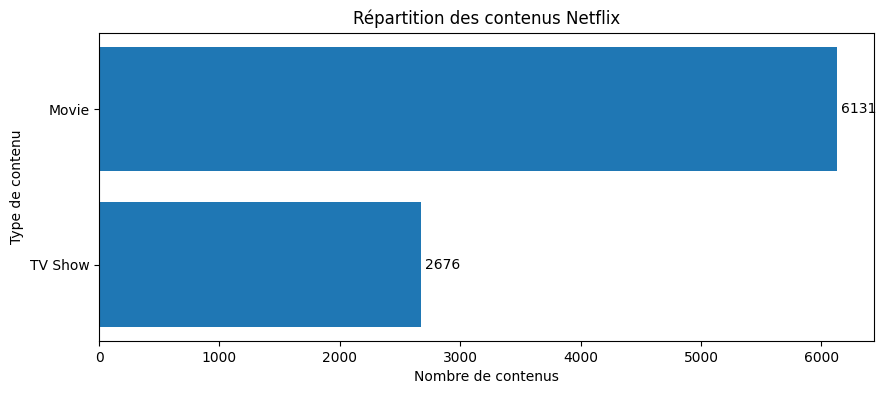

In [105]:
# Compter le nombre de contenus par type (Movie et TV Show)
type_counts = df["type"].value_counts()

# Trier les résultats du plus grand au plus petit
type_counts = type_counts.sort_values(ascending=False)

# Créer le graphique en barres horizontales
plt.figure(figsize=(10,4))
plt.barh(type_counts.index, type_counts.values)

# Ajouter les valeurs sur les barres
for i, valeur in enumerate(type_counts.values):
    plt.text(valeur + 30, i, str(valeur), va="center")

# Ajouter un titre et les étiquettes
plt.title("Répartition des contenus Netflix")
plt.xlabel("Nombre de contenus")
plt.ylabel("Type de contenu")

# Inverser l'axe Y pour afficher Movie en premier
plt.gca().invert_yaxis()

# Afficher le graphique
plt.show()

In [106]:
# Compter le nombre de contenus par année de sortie
release_counts = df["release_year"].value_counts().sort_index()


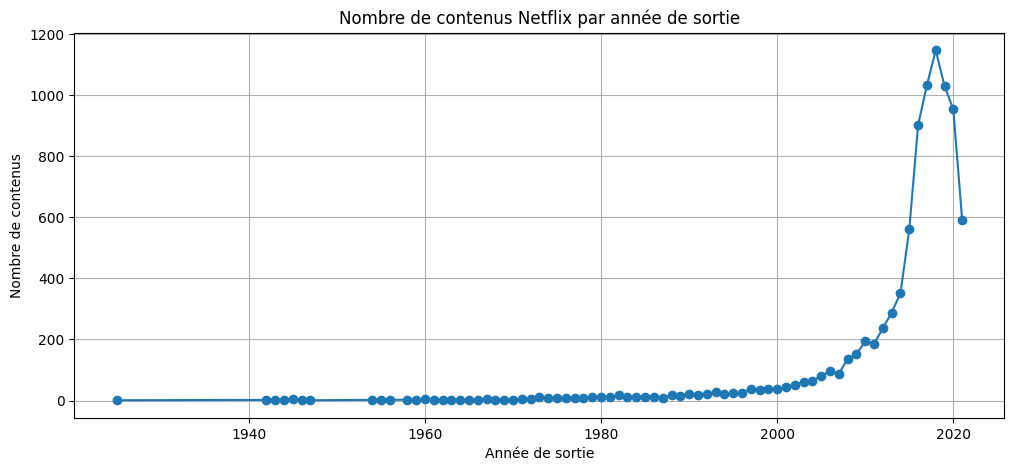

In [107]:
# Créer un graphique de la répartition des contenus par année de sortie
plt.figure(figsize=(12,5))
plt.plot(release_counts.index, release_counts.values, marker="o")

# Ajouter un titre et les étiquettes
plt.title("Nombre de contenus Netflix par année de sortie")
plt.xlabel("Année de sortie")
plt.ylabel("Nombre de contenus")

# Afficher le graphique
plt.grid(True)
plt.show()

In [108]:
# Compter le nombre de contenus par classification d'âge (rating)
rating_counts = df["rating"].value_counts()


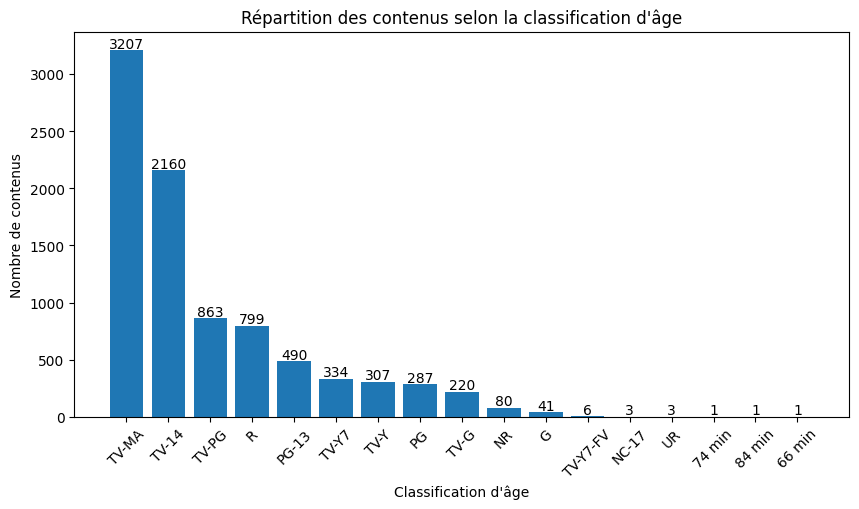

In [109]:
# Créer un graphique des classifications d'âge
plt.figure(figsize=(10,5))
plt.bar(rating_counts.index, rating_counts.values)

# Ajouter les valeurs sur les barres
for i, valeur in enumerate(rating_counts.values):
    plt.text(i, valeur + 20, str(valeur), ha="center")

# Ajouter un titre et les étiquettes
plt.title("Répartition des contenus selon la classification d'âge")
plt.xlabel("Classification d'âge")
plt.ylabel("Nombre de contenus")

# Faire pivoter les étiquettes pour une meilleure lisibilité
plt.xticks(rotation=45)

# Afficher le graphique
plt.show()

In [110]:
# Séparer les pays et compter le nombre de contenus par pays
country_counts = (
    df["country"]
    .dropna()
    .str.split(", ")
    .explode()
    .value_counts()
)


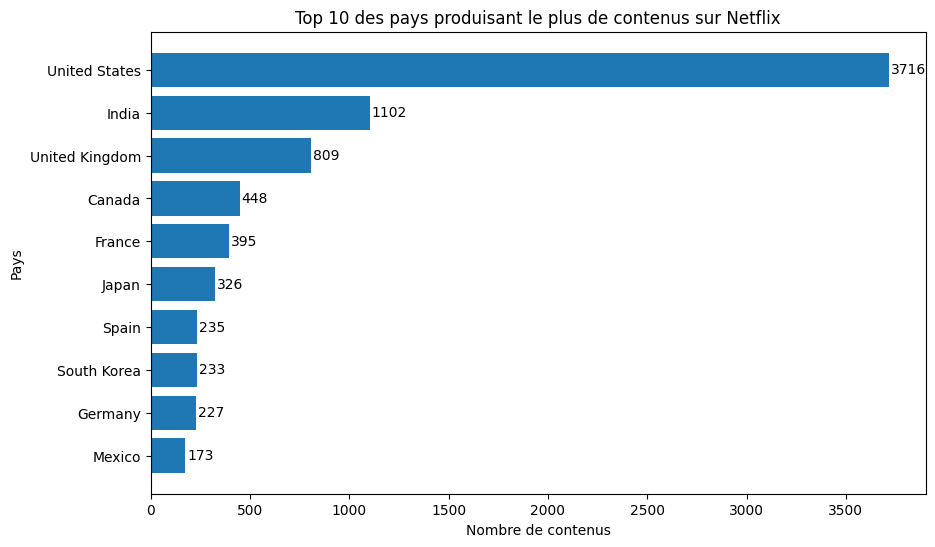

In [111]:
# Créer un graphique des 10 pays les plus représentés
plt.figure(figsize=(10,6))
top10 = country_counts.head(10)

plt.barh(top10.index, top10.values)

# Ajouter les valeurs sur les barres
for i, valeur in enumerate(top10.values):
    plt.text(valeur + 10, i, str(valeur), va="center")

# Ajouter un titre et les étiquettes
plt.title("Top 10 des pays produisant le plus de contenus sur Netflix")
plt.xlabel("Nombre de contenus")
plt.ylabel("Pays")

# Afficher le pays ayant le plus de contenus en haut
plt.gca().invert_yaxis()

# Afficher le graphique
plt.show()

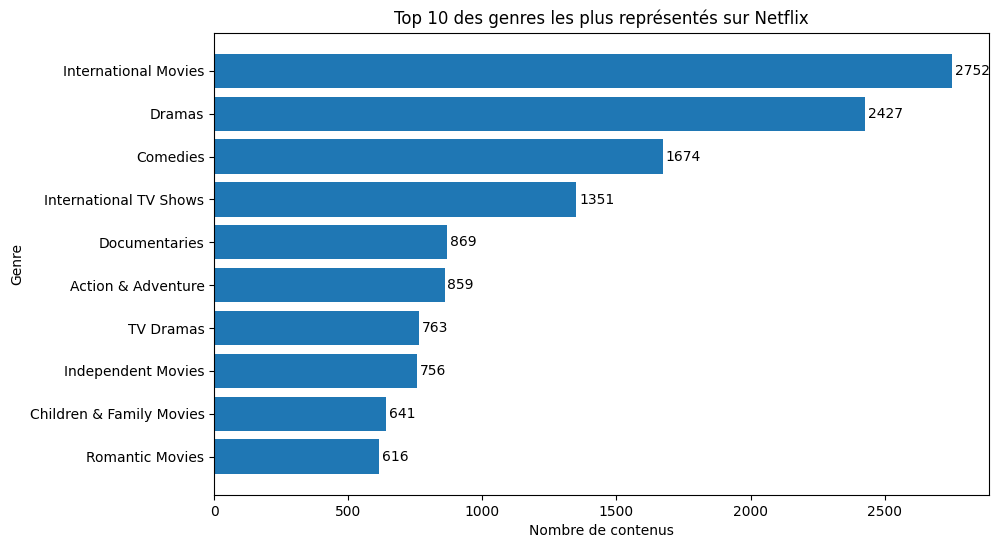

In [112]:
# Séparer les genres et compter leur fréquence
genre_counts = (
    df["listed_in"]
    .str.split(", ")
    .explode()
    .value_counts()
)

# Créer un graphique des 10 genres les plus représentés
plt.figure(figsize=(10,6))

top10 = genre_counts.head(10)

plt.barh(top10.index, top10.values)

# Ajouter les valeurs sur les barres
for i, valeur in enumerate(top10.values):
    plt.text(valeur + 10, i, str(valeur), va="center")

# Ajouter un titre et les étiquettes
plt.title("Top 10 des genres les plus représentés sur Netflix")
plt.xlabel("Nombre de contenus")
plt.ylabel("Genre")

# Afficher le genre le plus représenté en haut
plt.gca().invert_yaxis()

# Afficher le graphique
plt.show()

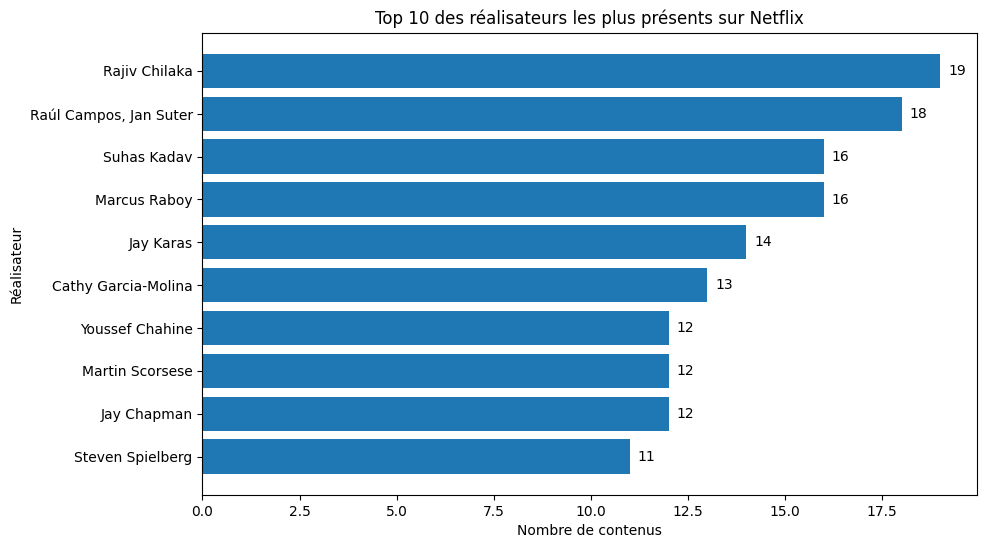

In [113]:
# Compter le nombre de contenus réalisés par chaque réalisateur
director_counts = df["director"].dropna().value_counts()

# Créer un graphique des 10 réalisateurs les plus présents
plt.figure(figsize=(10,6))

top10_directors = director_counts.head(10)

plt.barh(top10_directors.index, top10_directors.values)

# Ajouter les valeurs sur les barres
for i, valeur in enumerate(top10_directors.values):
    plt.text(valeur + 0.2, i, str(valeur), va="center")

# Ajouter un titre et les étiquettes
plt.title("Top 10 des réalisateurs les plus présents sur Netflix")
plt.xlabel("Nombre de contenus")
plt.ylabel("Réalisateur")

# Afficher le réalisateur le plus présent en haut
plt.gca().invert_yaxis()

# Afficher le graphique
plt.show()

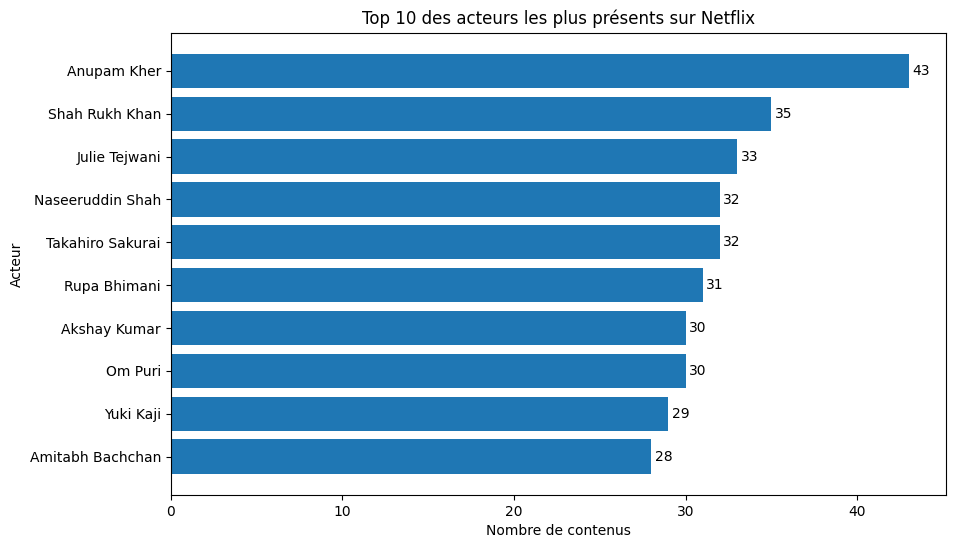

In [114]:
# Séparer les acteurs et compter leur fréquence
actor_counts = (
    df["cast"]
    .dropna()
    .str.split(", ")
    .explode()
    .value_counts()
)

# Créer un graphique des 10 acteurs les plus présents
plt.figure(figsize=(10,6))

top10_actors = actor_counts.head(10)

plt.barh(top10_actors.index, top10_actors.values)

# Ajouter les valeurs sur les barres
for i, valeur in enumerate(top10_actors.values):
    plt.text(valeur + 0.2, i, str(valeur), va="center")

# Ajouter un titre et les étiquettes
plt.title("Top 10 des acteurs les plus présents sur Netflix")
plt.xlabel("Nombre de contenus")
plt.ylabel("Acteur")

# Afficher l'acteur le plus présent en haut
plt.gca().invert_yaxis()

# Afficher le graphique
plt.show()


### Insights (Observations)



- Les films représentent la majorité des contenus disponibles sur Netflix.
- Les catégories International Movies, Dramas et Comedies sont les plus représentées.
- Plusieurs colonnes présentent des valeurs manquantes, principalement director, cast, country et date_added.
- Une partie des pays manquants a pu être retrouvée grâce aux réalisateurs associés à un seul pays connu.
- Les acteurs et réalisateurs les plus fréquents montrent une forte présence de productions indiennes sur la plateforme.
- Les données restantes sont globalement cohérentes après les différentes étapes de nettoyage.


### Recommandations

- Continuer à investir dans les films internationaux, car ils représentent la catégorie la plus présente sur la plateforme.
- Renforcer la production de contenus dramatiques et de comédies, qui figurent parmi les genres les plus populaires du catalogue.
- Développer davantage de séries TV, afin d'équilibrer le catalogue entre films et séries.
- Collaborer davantage avec les réalisateurs et acteurs les plus présents, puisqu'ils contribuent fortement au contenu de la plateforme.
- Améliorer la qualité des métadonnées (pays, réalisateurs, casting, date d'ajout) afin de faciliter les recherches, les recommandations personnalisées et les analyses futures.
- Diversifier davantage les contenus provenant de régions moins représentées, afin d'attirer un public plus international.

# ============================================================
# Conclusion générale de l'analyse exploratoire du dataset Netflix
# ============================================================

Au cours de cette analyse exploratoire, nous avons étudié la qualité des données
ainsi que les principales caractéristiques des contenus présents sur Netflix.

Les principales observations sont les suivantes :

- Le dataset est composé majoritairement de films (Movies), tandis que les séries TV (TV Shows) sont moins nombreuses.
- Les genres les plus représentés sont International Movies, Dramas et Comedies.
- Plusieurs colonnes contenaient des valeurs manquantes, notamment :
    * director
    * cast
    * country
    * date_added
    * rating
    * duration
- Une analyse détaillée de la colonne 'country' a permis de récupérer une partie
  des pays manquants en utilisant les réalisateurs associés à un seul pays connu.
- Les valeurs manquantes restantes n'ont pas été remplacées lorsqu'aucune preuve
  fiable ne permettait d'identifier le pays, afin de préserver la qualité des données.
- Les espaces inutiles présents dans les colonnes textuelles ont été supprimés.
- Aucune anomalie importante n'a été détectée concernant les identifiants des contenus.
- Les analyses montrent que Netflix propose principalement des films internationaux
  et des contenus dramatiques.
- Les acteurs et réalisateurs les plus présents ont été identifiés grâce aux analyses
  de fréquence.

En conclusion, après le nettoyage des données et l'analyse exploratoire,
le dataset est désormais suffisamment propre et cohérent pour réaliser
des analyses plus avancées ou construire des tableaux de bord avec Power BI
ou d'autres outils de visualisation.


In [115]:
# Dataset nettoyé
df.to_csv("cleaned_netflix_titles.csv", index=False)